In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
1.78*0.01756*10**-1.1 + 0.248

0.250482815876713

In [3]:
df_full = pd.read_hdf('../../grids/Chiara.hdf5', key='df')
df_small = df_full.sample(10000)

In [129]:
Y25 = pd.read_csv('../M4_seismicanalysis_Yingxiang_Feb25.csv')
Y25 = Y25[(Y25['Quality_flag'] == 'D')&(Y25['evol_stage'] == 'RGB')&(Y25['numax_pyMon']>12)&(Y25['Delta_nu']>0)].reset_index()

numax = Y25['numax_pyMon']
enumax_obs = Y25['numax_err_pyMon']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = Y25['Delta_nu']
ednu_obs = 0.03*Y25['Delta_nu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = Y25['Lum_bol']
eLPhot_obs = np.sqrt(Y25['Lum_bol_err_random']**2 + Y25['Lum_bol_err_systematic']**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = Y25['Teff_final']
eTeff = Y25['Teff_err_final']

num_stars = len(Teff)

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values)}
unc = {'Teff':eTeff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10)}


In [130]:
Y25

,index,star_id,evol_stage,Gaia_source_ID_DR3,2MASS_ID,Gmag,Quality_flag,numax_pyMon,numax_err_pyMon,Teff_final,Teff_err_final,Lum_bol,Lum_bol_err_random,Lum_bol_err_systematic,Mass,Mass_err_rand,Delta_nu,delta_nu_02,epsilon
0,3,M4RGB165,RGB,6.050000e+18,16230993-2628335,13.98,D,91.848136,2.085416,5287,108.001212,22.97,0.44,2.69,0.93,0.07,8.35,NaN,0.920
1,13,M4RGB188,RGB,6.050000e+18,16232169-2626468,13.04,D,30.981079,0.568750,4810,108.001212,44.00,1.53,5.11,0.84,0.07,3.75,NaN,0.600
2,15,M4RGB104,RGB,6.050000e+18,16232195-2630320,13.13,D,33.730326,0.568750,4851,108.001212,38.85,1.28,4.51,0.78,0.06,4.32,0.130,0.926
3,16,M4RGB17,RGB,6.050000e+18,16232252-2629422,13.54,D,51.888145,0.710937,4785,61.000000,28.35,0.60,3.29,0.92,0.05,5.84,0.170,1.230
4,22,M4RGB13,RGB,6.050000e+18,16232508-2629530,13.52,D,49.202833,1.990624,4840,108.001212,26.95,0.90,3.12,0.79,0.07,6.39,0.120,1.290
5,27,M4RGB229,RGB,6.050000e+18,16232982-2623253,12.49,D,15.949854,0.178361,4677,54.000000,73.89,1.62,8.58,0.80,0.04,2.66,0.190,0.920
6,32,M4RGB23,RGB,6.050000e+18,16233236-2629222,13.36,D,42.553491,1.042708,4897,108.001212,31.25,0.97,3.62,0.77,0.06,5.39,0.130,1.080
7,35,M4RGB37,RGB,6.050000e+18,16233380-2627497,13.14,D,35.136918,0.663541,4821,108.001212,39.61,1.35,4.60,0.85,0.07,4.86,0.170,0.890
8,36,M4RGB129,RGB,6.050000e+18,16233414-2630104,13.76,D,70.173835,1.990624,4989,108.001212,22.63,0.62,2.63,0.86,0.07,7.35,0.130,1.240
9,44,M4RGB252,RGB,6.050000e+18,16233768-2620381,13.57,D,55.276752,0.663541,5012,60.000000,26.65,0.41,3.09,0.78,0.04,5.84,0.130,1.050


In [13]:
T22 = pd.read_csv('../../data/Tailo_2022_table_1.csv')
T22 = T22[(T22['POPCUBI'] == '1G')|(T22['POPCUBI'] == '2G')]
T22['Dnu'] = T22['dnu'].str.split('±', expand = True)[0]
T22['eDnu'] = T22['dnu'].str.split('±', expand = True)[1]
T22['Numax'] = T22['numax'].str.split('±', expand = True)[0]
T22['eNumax'] = T22['numax'].str.split('±', expand = True)[1]
T22['LPhot'] = T22['lum'].str.split('±', expand = True)[0]
T22['eLPhot'] = T22['lum'].str.split('±', expand = True)[1]


In [14]:
Tailo = pd.DataFrame(columns = ['LPhot', 'eLPhot', 'Teff', 'numax', 'enumax', 'dnu', 'ednu'])
Tailo['LPhot'] = T22['LPhot'].astype(float)
Tailo['eLPhot'] = T22['eLPhot'].astype(float)
Tailo['Teff'] = T22['Teff'].astype(float)
Tailo['numax'] = T22['Numax'].astype(float)
Tailo['enumax'] = T22['eNumax'].astype(float)
Tailo['dnu'] = T22['Dnu'].astype(float)
Tailo['ednu'] = T22['eDnu'].astype(float)
Tailo['WID'] = T22['WID']
Tailo['POPCUBI'] = T22['POPCUBI']
Tailo.to_csv('../../data/Tailo_2022_processed.csv', index = False)

In [148]:
import glob
import arviz as az

IDs_ = glob.glob('../../inference-objects/dnufit/W*.json')

IDs_ = [i.split('../../inference-objects/dnufit/')[1].split('.json')[0] for i in IDs_]

keys = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']

pos_dict = dict.fromkeys(keys)

prior_dict = dict.fromkeys(keys)

for i in range(len(IDs_)):
    
    star_id = IDs_[i]
    
    data = az.from_json(f'../../inference-objects/dnufit/{star_id}.json')
    if i == 0:
        for j in keys:
            pos_dict[j] = np.array(data['posterior'][j])
            prior_dict[j] = np.array(data['prior'][j])
    else:
        for j in keys:
            pos_dict[j] = np.vstack((pos_dict[j], np.array(data['posterior'][j])))
            prior_dict[j] = np.vstack((prior_dict[j], np.array(data['prior'][j])))

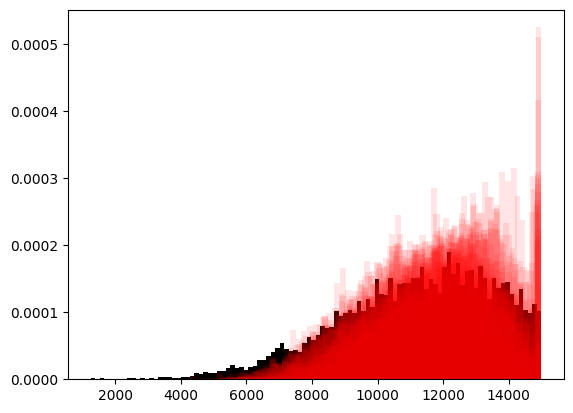

In [149]:
plt.hist(prior_dict['age'][0].T[0], density = True, color = 'black', bins = 100)
for i in range(0,len(pos_dict['age'])):
        plt.hist(pos_dict['age'][i].T[0], alpha = 0.1, density = True, color = 'red', bins = 50)



In [151]:
ages = pos_dict['age'][0].T[0]

for i in range(1, len(pos_dict['age'])):   
    
    ages = np.concat((ages, pos_dict['age'][i].T[0]))

    
ages    

ValueError: operands could not be broadcast together with shapes (4000,) (8000,) (4000,) 

array([1.89601360e+08, 1.89192077e+08, 1.78251821e+08, ...,
       1.18528403e+08, 1.29717034e+08, 1.34927435e+08])

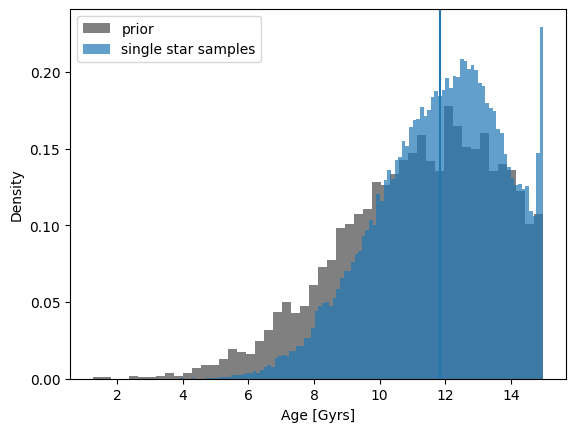

In [236]:
plt.hist(prior_dict['age'][0].T[0]/10**3, density = True, bins = 50, color = 'grey', label = 'prior')
plt.hist(ages/10**3, bins = 100, density = True, alpha = 0.7, label = 'single star samples')
plt.legend()
plt.xlabel('Age [Gyrs]')
plt.ylabel('Density')
plt.axvline(np.mean(ages)/10**3)
#plt.savefig('../figs/single-star-inference-combined-age-Tailo.png', bbox_inches = 'tight')

Text(0, 0.5, 'Density')

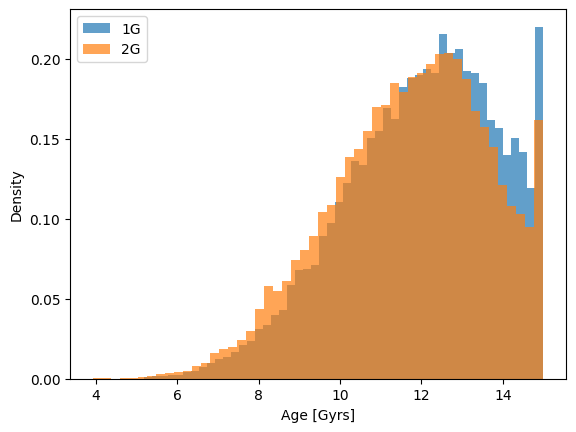

In [232]:
ages2G = pos_dict['age'][0].T[0]
ages1G = pos_dict['age'][1].T[0]
for i in np.where(np.array(pops) == '2G')[0]:   

    ages2G = np.concat((ages2G, pos_dict['age'][i].T[0]))

for i in np.where(np.array(pops) == '1G')[0]:   
    
    ages1G = np.concat((ages1G, pos_dict['age'][i].T[0]))

#plt.hist(prior_dict['age'][0].T[0]/10**3, density = True, bins = 50, color = 'grey', label = 'prior')
plt.hist(ages1G/10**3, bins = 50, density = True, alpha = 0.7, label = '1G')
plt.hist(ages2G/10**3, bins = 50, density = True, alpha = 0.7, label = '2G')

plt.legend()
plt.xlabel('Age [Gyrs]')
plt.ylabel('Density')

In [21]:
MC = pd.read_csv('../../data/Marino_2008_classicals.txt')
MS = pd.read_csv('../../data/Marino_2008_abundances.txt')

M08 = pd.merge(MC, MS, on = 'Star')
M08['alphaFe'] = 0.25*(M08['[Mg/Fe]'] + M08['[Si/Fe]'] + M08['[Ca/Fe]'] + M08['[Ti/FeI]'])
#match = T22[~(T22['POPSpec'] == '–')].reset_index()

In [82]:
match['RA'] = match['RA (J2000)'].astype(float)
match['Dec'] = -1*match['Dec (J2000)'].str.split('–', expand = True)[1].astype(float)
match['Teff'] = match['Teff'].astype(float)

In [83]:
M08T22 = pd.DataFrame(columns = M08.columns.values, index = match.index)
for k, v in match.iterrows(): 
    i = ((M08['RAdeg']-v['RA']) * \
       (np.abs(M08['DEdeg'])-np.abs(v['Dec'])) * \
       (M08['Teff']-v['Teff'])).abs().idxmin() 

    M08T22.iloc[k] = M08.iloc[i]



In [103]:
abundances = pd.concat([match, M08T22], axis = 1).drop('Unnamed: 0', axis = 1)
wrong = ['W491', 'W3742', 'W1763']
abundances = abundances[~(abundances['WID'].isin(wrong))]


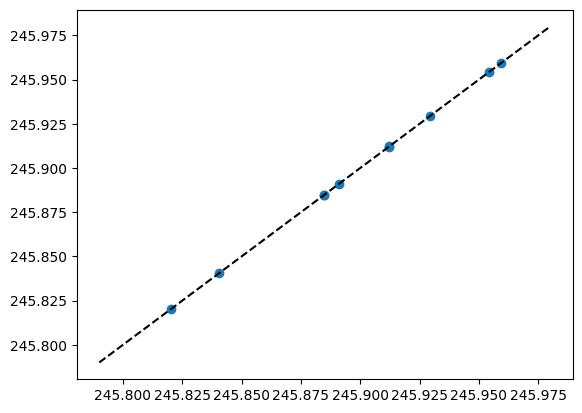

In [104]:
plt.scatter(abundances['RA'], abundances['RAdeg'])
plt.plot(np.linspace(245.79, 245.98), np.linspace(245.79, 245.98), linestyle = '--', color = 'black')

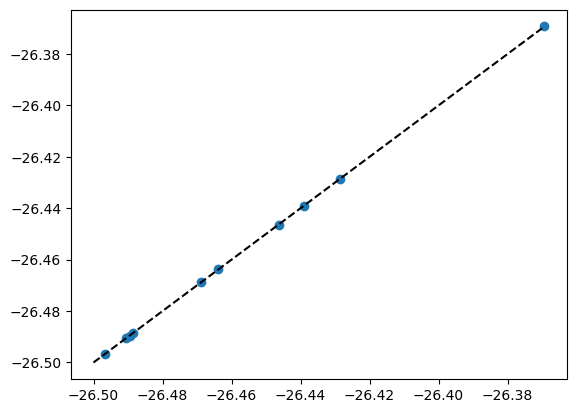

In [105]:
plt.scatter(abundances['Dec'], abundances['DEdeg'])
plt.plot(np.linspace(-26.5, -26.37), np.linspace(-26.5, -26.37), linestyle = '--', color = 'black')

(np.float64(0.38738095238095244), np.float64(0.0244593466222671))

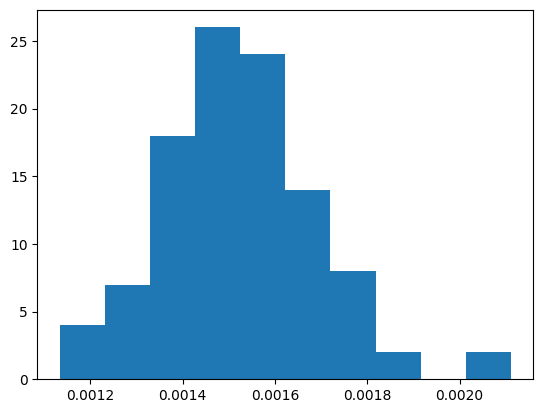

In [125]:
plt.hist(0.01756*10**M08['[Fe/HI]'])
np.mean(M08['alphaFe']), np.std(M08['alphaFe'])

np.float64(0.31400291251415113)

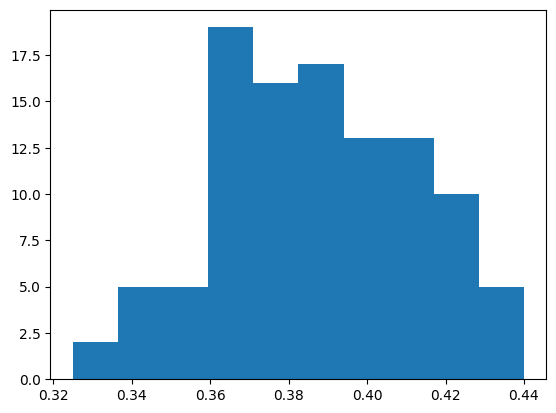

In [159]:
plt.hist(M08['alphaFe'])
np.mean(M08['alphaFe']) - 3*np.std(M08['alphaFe'])


In [112]:
abundances['alphaFe']= 0.25*(abundances['[Mg/Fe]'] + abundances['[Si/Fe]'] + abundances['[Ca/Fe]'] + abundances['[Ti/FeI]'])

In [115]:
abundances[['WID', 'Teff', 'Numax', 'eNumax', 'Dnu', 'eDnu', 'LPhot', 'eLPhot', '[Fe/HI]', 'alphaFe']].to_csv('../../data/T22M08.csv')

In [116]:
abundances[['WID', 'Teff', 'Numax', 'eNumax', 'Dnu', 'eDnu', 'LPhot', 'eLPhot', '[Fe/HI]', 'alphaFe']]

,WID,Teff,Teff,Numax,eNumax,Dnu,eDnu,LPhot,eLPhot,[Fe/HI],alphaFe
1,W760 ( * ),4668.0,4700.0,18.148,1.024,2.558,0.081,71.180,7.748,-1.06,0.3475
2,W1091,4787.0,4800.0,31.402,1.722,3.899,0.296,48.529,5.227,-1.07,0.4175
4,W2021,4841.0,4880.0,44.785,1.422,5.374,0.229,32.030,3.448,-0.99,0.355
5,W2022 ( * ),4677.0,4730.0,15.986,1.047,2.418,0.085,77.933,8.468,-1.08,0.41
6,W2162,4782.0,4790.0,35.280,1.784,4.245,0.359,41.995,4.528,-1.11,0.385
7,W2665 ( * ),4675.0,4760.0,17.806,0.445,2.526,0.089,73.824,8.007,-1.02,0.39
8,W2678,4805.0,4800.0,31.495,0.878,3.862,0.300,45.290,4.884,-1.03,0.415
9,W3033 ( * ),4785.0,4820.0,32.892,1.396,4.102,0.334,44.566,4.798,-1.03,0.3725
10,W3480,4875.0,4830.0,45.087,1.775,5.228,0.182,34.725,3.550,-1.08,0.3825
11,W3564,4803.0,4850.0,31.958,2.938,4.029,0.230,47.534,5.117,-1.0,0.3625


In [3]:
T22 = pd.read_csv('../../data/Tailo_2022_processed.csv')

remove = []

T22 = T22[~(T22['WID'].isin(remove))].reset_index()

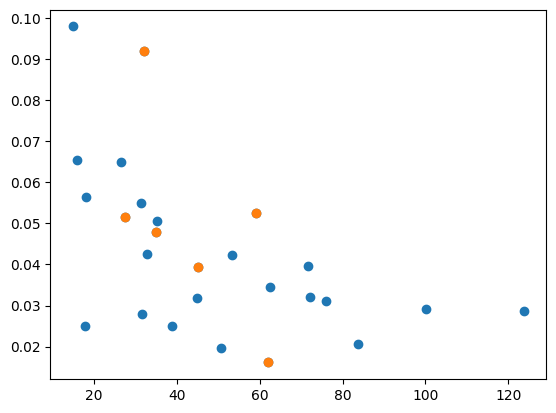

In [26]:
plt.scatter(T22['numax'], T22['enumax']/T22['numax'])
plt.scatter(T22[20:]['numax'], T22[20:]['enumax']/T22[20:]['numax'])

In [5]:
T22M08 = pd.read_csv('../../data/T22M08.csv')

In [9]:
nomet = T22[~T22['WID'].isin(T22M08['WID'])]['WID'].values


In [17]:
nomet
for i in range(len(nomet)):
    new = pd.DataFrame(columns = T22M08.columns)
    WID = nomet[i]
    new.loc[0, 'Teff_M08'] = T22[T22['WID'] == WID]['Teff'].values[0]
    new.loc[0, '[Fe/HI]'] = np.mean(T22M08['[Fe/HI]'])
    new.loc[0, 'alphaFe'] = np.mean(T22M08['alphaFe'])
    for j in T22.columns:
        new.loc[0, j] = T22[T22['WID'] == WID][j].values[0]
    T22M08 = pd.concat([T22M08, new])

In [22]:
T22M08.drop(['Unnamed: 0', 'index', 'POPCUBI'], axis = 1).to_csv('../../data/T22M08.csv', index = False)

In [32]:
M22 = pd.read_csv('../../data/M4RGB_ps/M4_seismicanalysis.csv')
loc = pd.read_csv('../../data/M22-RA-DEC.csv')

match = M22.merge(loc, on = 'Gaia_source_ID_DR3')

In [34]:
M08M22 = pd.DataFrame(columns = M08.columns.values, index = match.index)
for k, v in match.iterrows(): 
    i = ((M08['RAdeg']-v['RA']) * \
       (np.abs(M08['DEdeg'])-np.abs(v['Dec'])) * \
       (M08['Teff']-v['Teff_final'])).abs().idxmin() 

    M08M22.iloc[k] = M08.iloc[i]

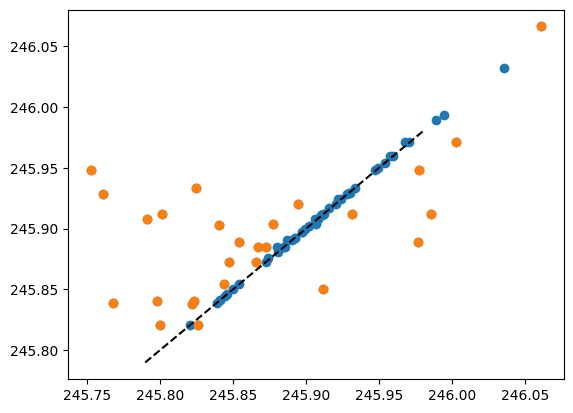

In [38]:
abundances = pd.concat([match, M08M22], axis = 1)

plt.scatter(abundances['RA'], abundances['RAdeg'])
plt.scatter(abundances[np.abs(abundances['RA'] - abundances['RAdeg']) > 0.005]['RA'], abundances[np.abs(abundances['RA'] - abundances['RAdeg']) > 0.005]['RAdeg'])
plt.plot(np.linspace(245.79, 245.98), np.linspace(245.79, 245.98), linestyle = '--', color = 'black')


In [54]:
abundances['alphaFe']= 0.25*(abundances['[Mg/Fe]'] + abundances['[Si/Fe]'] + abundances['[Ca/Fe]'] + abundances['[Ti/FeI]'])
ramatch =  abundances[~(np.abs(abundances['RA'] - abundances['RAdeg']) > 0.005)]

In [45]:
abundances[~(np.abs(abundances['RA'] - abundances['RAdeg']) > 0.005)&(abundances['evol_stage'] == 'RGB')&(abundances['numax_pyMon'] > 15)].to_csv('../../data/M22-with-abundances.csv', index = False)

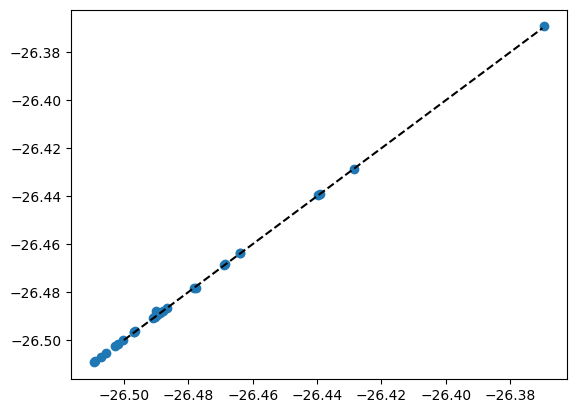

In [50]:
plt.scatter(ramatch[np.abs(ramatch['DEdeg'] - ramatch['Dec']) < 0.005]['Dec'], ramatch[np.abs(ramatch['DEdeg'] - ramatch['Dec']) < 0.005]['DEdeg'])
plt.plot(np.linspace(-26.5, -26.37), np.linspace(-26.5, -26.37), linestyle = '--', color = 'black')

In [55]:
decmatch = ramatch[np.abs(ramatch['DEdeg'] - ramatch['Dec']) < 0.005]
decmatch[(decmatch['evol_stage'] == 'RGB')&(decmatch['numax_pyMon'] > 15)].to_csv('../../data/M22-with-abundances.csv', index = False)

In [56]:
M22['[Fe/HI]'] = -1.047*np.ones_like(M22['star_id'])
M22['alphaFe'] = 0.38375*np.ones_like(M22['star_id'])
for i in range(len(M22)):
    try:
        ID = M22.loc[i, 'star_id']
        M22.loc[i, '[Fe/HI]'] = decmatch[decmatch['star_id'] == ID]['[Fe/HI]'].values[0]
        M22.loc[i, 'alphaFe'] = decmatch[decmatch['star_id'] == ID]['alphaFe'].values[0]
    except:
        pass
        

In [59]:
M22[(M22['evol_stage'] == 'RGB')&(M22['numax_pyMon'] > 15)].to_csv('../../data/M22-with-abundances.csv', index = False)

In [60]:
M22 = pd.read_csv('../../data/M4RGB_ps/M4_seismicanalysis.csv')
pbjam = pd.read_csv('../../data/pbjam-results-dnu-numax-maddy.csv')

M22 = M22.merge(pbjam, on = 'star_id')

M22 = M22[~M22['star_id'].isin(['M4RGB252', 'M4RGB238', 'M4RGB217', 'M4RGB165', 'M4RGB131', 'M4RGB34', 'M4RGB25', 'M4RGB22', 'M4RGB16'])].reset_index()

T22 = pd.read_csv('../../data/T22M08.csv')
pbjam = pd.read_csv('../../data/pbjam-results-dnu-numax-marco.csv')

T22 = T22.merge(pbjam, on = 'WID')

T22 = T22[~T22['WID'].isin(['W1763', 'W2034', 'W1912', 'W760',])].reset_index()




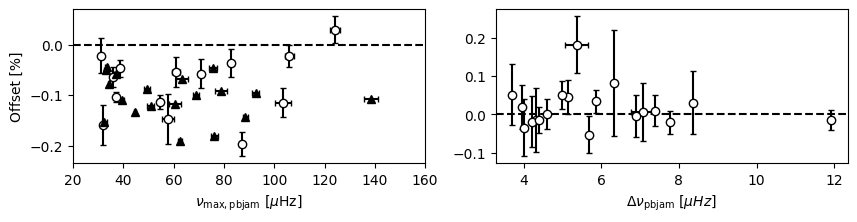

In [83]:
fig,axs = plt.subplots(figsize = (10, 2), nrows = 1, ncols = 2)

err_ratio_numax = np.sqrt(M22['numax_pyMon']**2/M22['numax_pbjam']**4*M22['enumax_pbjam']**2 + M22['numax_err_pyMon']**2/M22['numax_pbjam']**2)
err_ratio_dnu = np.sqrt(T22['dnu']**2/T22['dnu_pbjam']**4*T22['ednu_pbjam']**2 + T22['ednu']**2/T22['dnu_pbjam']**2)

axs[0].errorbar(M22['numax_pbjam'], (M22['numax_pyMon'] - M22['numax_pbjam'])/M22['numax_pbjam'], yerr = err_ratio_numax,  xerr = M22['enumax_pbjam'], fmt = 'o', capsize = 2,  color = 'black', markeredgecolor = 'black', markerfacecolor = 'white')
axs[0].errorbar(T22['numax_pbjam'], (T22['numax'] - T22['numax_pbjam'])/T22['numax_pbjam'], xerr  = T22['enumax_pbjam'], fmt = '^', markeredgecolor = 'black', capsize = 2, color = 'black',)
#plt.plot(np.linspace(20, 160), np.linspace(20, 160), color = 'black', linestyle = '--')
axs[0].axhline(0, color = 'black', linestyle = '--')
axs[0].set_xlim(20, 160)
#ax.set_ylim(20, 160)
axs[0].set_xlabel(r'$\nu_{\mathrm{max, pbjam}}$ [$\mu$Hz]')
axs[0].set_ylabel(r'Offset [%]')
axs[1].errorbar(T22['dnu_pbjam'], (T22['dnu'] -T22['dnu_pbjam'])/T22['dnu_pbjam'], yerr = err_ratio_dnu, xerr  = T22['ednu_pbjam'], fmt = 'o', capsize = 2, color = 'black', markerfacecolor = 'white')
axs[1].axhline(0, color = 'black', linestyle = '--')
axs[1].set_xlabel(r'$\Delta \nu_{\mathrm{pbjam}}$ [$\mu Hz$]')

fig.savefig('../../figs/numax_dnu_offset.png', bbox_inches = 'tight', dpi = 150)

In [44]:
np.mean((M22['numax_pbjam'] - M22['numax_pyMon'])/M22['dnu_pbjam'])

np.float64(0.8360342918351498)

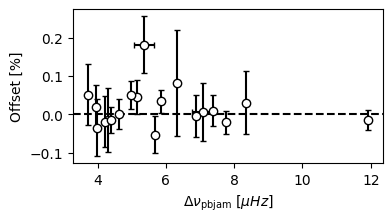

In [79]:
err_ratio_dnu = np.sqrt(T22['dnu']**2/T22['dnu_pbjam']**4*T22['ednu_pbjam']**2 + T22['ednu']**2/T22['dnu_pbjam']**2)

fig = plt.figure(figsize = (4, 2))
ax = plt.gca()
plt.errorbar(T22['dnu_pbjam'], (T22['dnu'] -T22['dnu_pbjam'])/T22['dnu_pbjam'], yerr = err_ratio_dnu, xerr  = T22['ednu_pbjam'], fmt = 'o', capsize = 2, color = 'black', markerfacecolor = 'white')
plt.axhline(0, color = 'black', linestyle = '--')
plt.xlabel(r'$\Delta \nu_{\mathrm{pbjam}}$ [$\mu Hz$]')
plt.ylabel(r'Offset [%]')
plt.savefig('../../figs/dnu_offset.png', bbox_inches = 'tight', dpi = 150)